# **Bài thực hành 3. Làm sạch và trực quan hóa dữ liệu**

## **3.1. Bài tập 1: Tiếp tục làm sạch dữ liệu**

In [1]:
import pandas as pd


In [5]:
df = pd.read_csv("/content/credit_card_clean_1.csv")

In [6]:
df.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,ceae2946-47e4,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,d3b8ce26-9c89,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,d6e1911b-54d0,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,8421d3b3-2b54,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,62a2fd79-cd90,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


In [9]:
# Xem thông tin các cột
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29685 entries, 0 to 29684
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          29685 non-null  object
 1   LIMIT_BAL                   29685 non-null  int64 
 2   SEX                         29685 non-null  int64 
 3   EDUCATION                   29685 non-null  int64 
 4   MARRIAGE                    29685 non-null  int64 
 5   AGE                         29685 non-null  int64 
 6   PAY_1                       29685 non-null  object
 7   PAY_2                       29685 non-null  int64 
 8   PAY_3                       29685 non-null  int64 
 9   PAY_4                       29685 non-null  int64 
 10  PAY_5                       29685 non-null  int64 
 11  PAY_6                       29685 non-null  int64 
 12  BILL_AMT1                   29685 non-null  int64 
 13  BILL_AMT2                   29685 non-null  in

In [10]:
print("10 giá trị đầu của PAY_1:")
print(df['PAY_1'].head(10))

print("\nThống kê giá trị trong PAY_1:")
print(df['PAY_1'].value_counts())

10 giá trị đầu của PAY_1:
0     2
1    -1
2     0
3     0
4    -1
5     0
6     0
7     0
8     0
9    -2
Name: PAY_1, dtype: object

Thống kê giá trị trong PAY_1:
PAY_1
0                13087
-1                5047
1                 3261
Not available     3021
-2                2476
2                 2378
3                  292
4                   63
5                   23
8                   17
6                   11
7                    9
Name: count, dtype: int64


In [11]:
valid_pay = df['PAY_1'] != 'Not available'

df_clean_2 = df.loc[valid_pay].copy()

print(f"Số lượng dòng còn lại: {df_clean_2.shape[0]}")

Số lượng dòng còn lại: 26664


In [13]:
df_clean_2['PAY_1'] = df_clean_2['PAY_1'].astype('int64')

print("Thông tin sau khi chuyển đổi kiểu dữ liệu:")
df_clean_2.info()

Thông tin sau khi chuyển đổi kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
Index: 26664 entries, 0 to 29684
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          26664 non-null  object
 1   LIMIT_BAL                   26664 non-null  int64 
 2   SEX                         26664 non-null  int64 
 3   EDUCATION                   26664 non-null  int64 
 4   MARRIAGE                    26664 non-null  int64 
 5   AGE                         26664 non-null  int64 
 6   PAY_1                       26664 non-null  int64 
 7   PAY_2                       26664 non-null  int64 
 8   PAY_3                       26664 non-null  int64 
 9   PAY_4                       26664 non-null  int64 
 10  PAY_5                       26664 non-null  int64 
 11  PAY_6                       26664 non-null  int64 
 12  BILL_AMT1                   26664 non-null  int64 
 13  BILL_AMT

In [14]:
df_clean_2.to_csv('credit_card_clean_2.csv', index=False)

print("Đã xuất file thành công!")

Đã xuất file thành công!


## **3.2. Bài tập 2. Khám phá Giới hạn Tín dụng và Đặc điểm Nhân khẩu học**

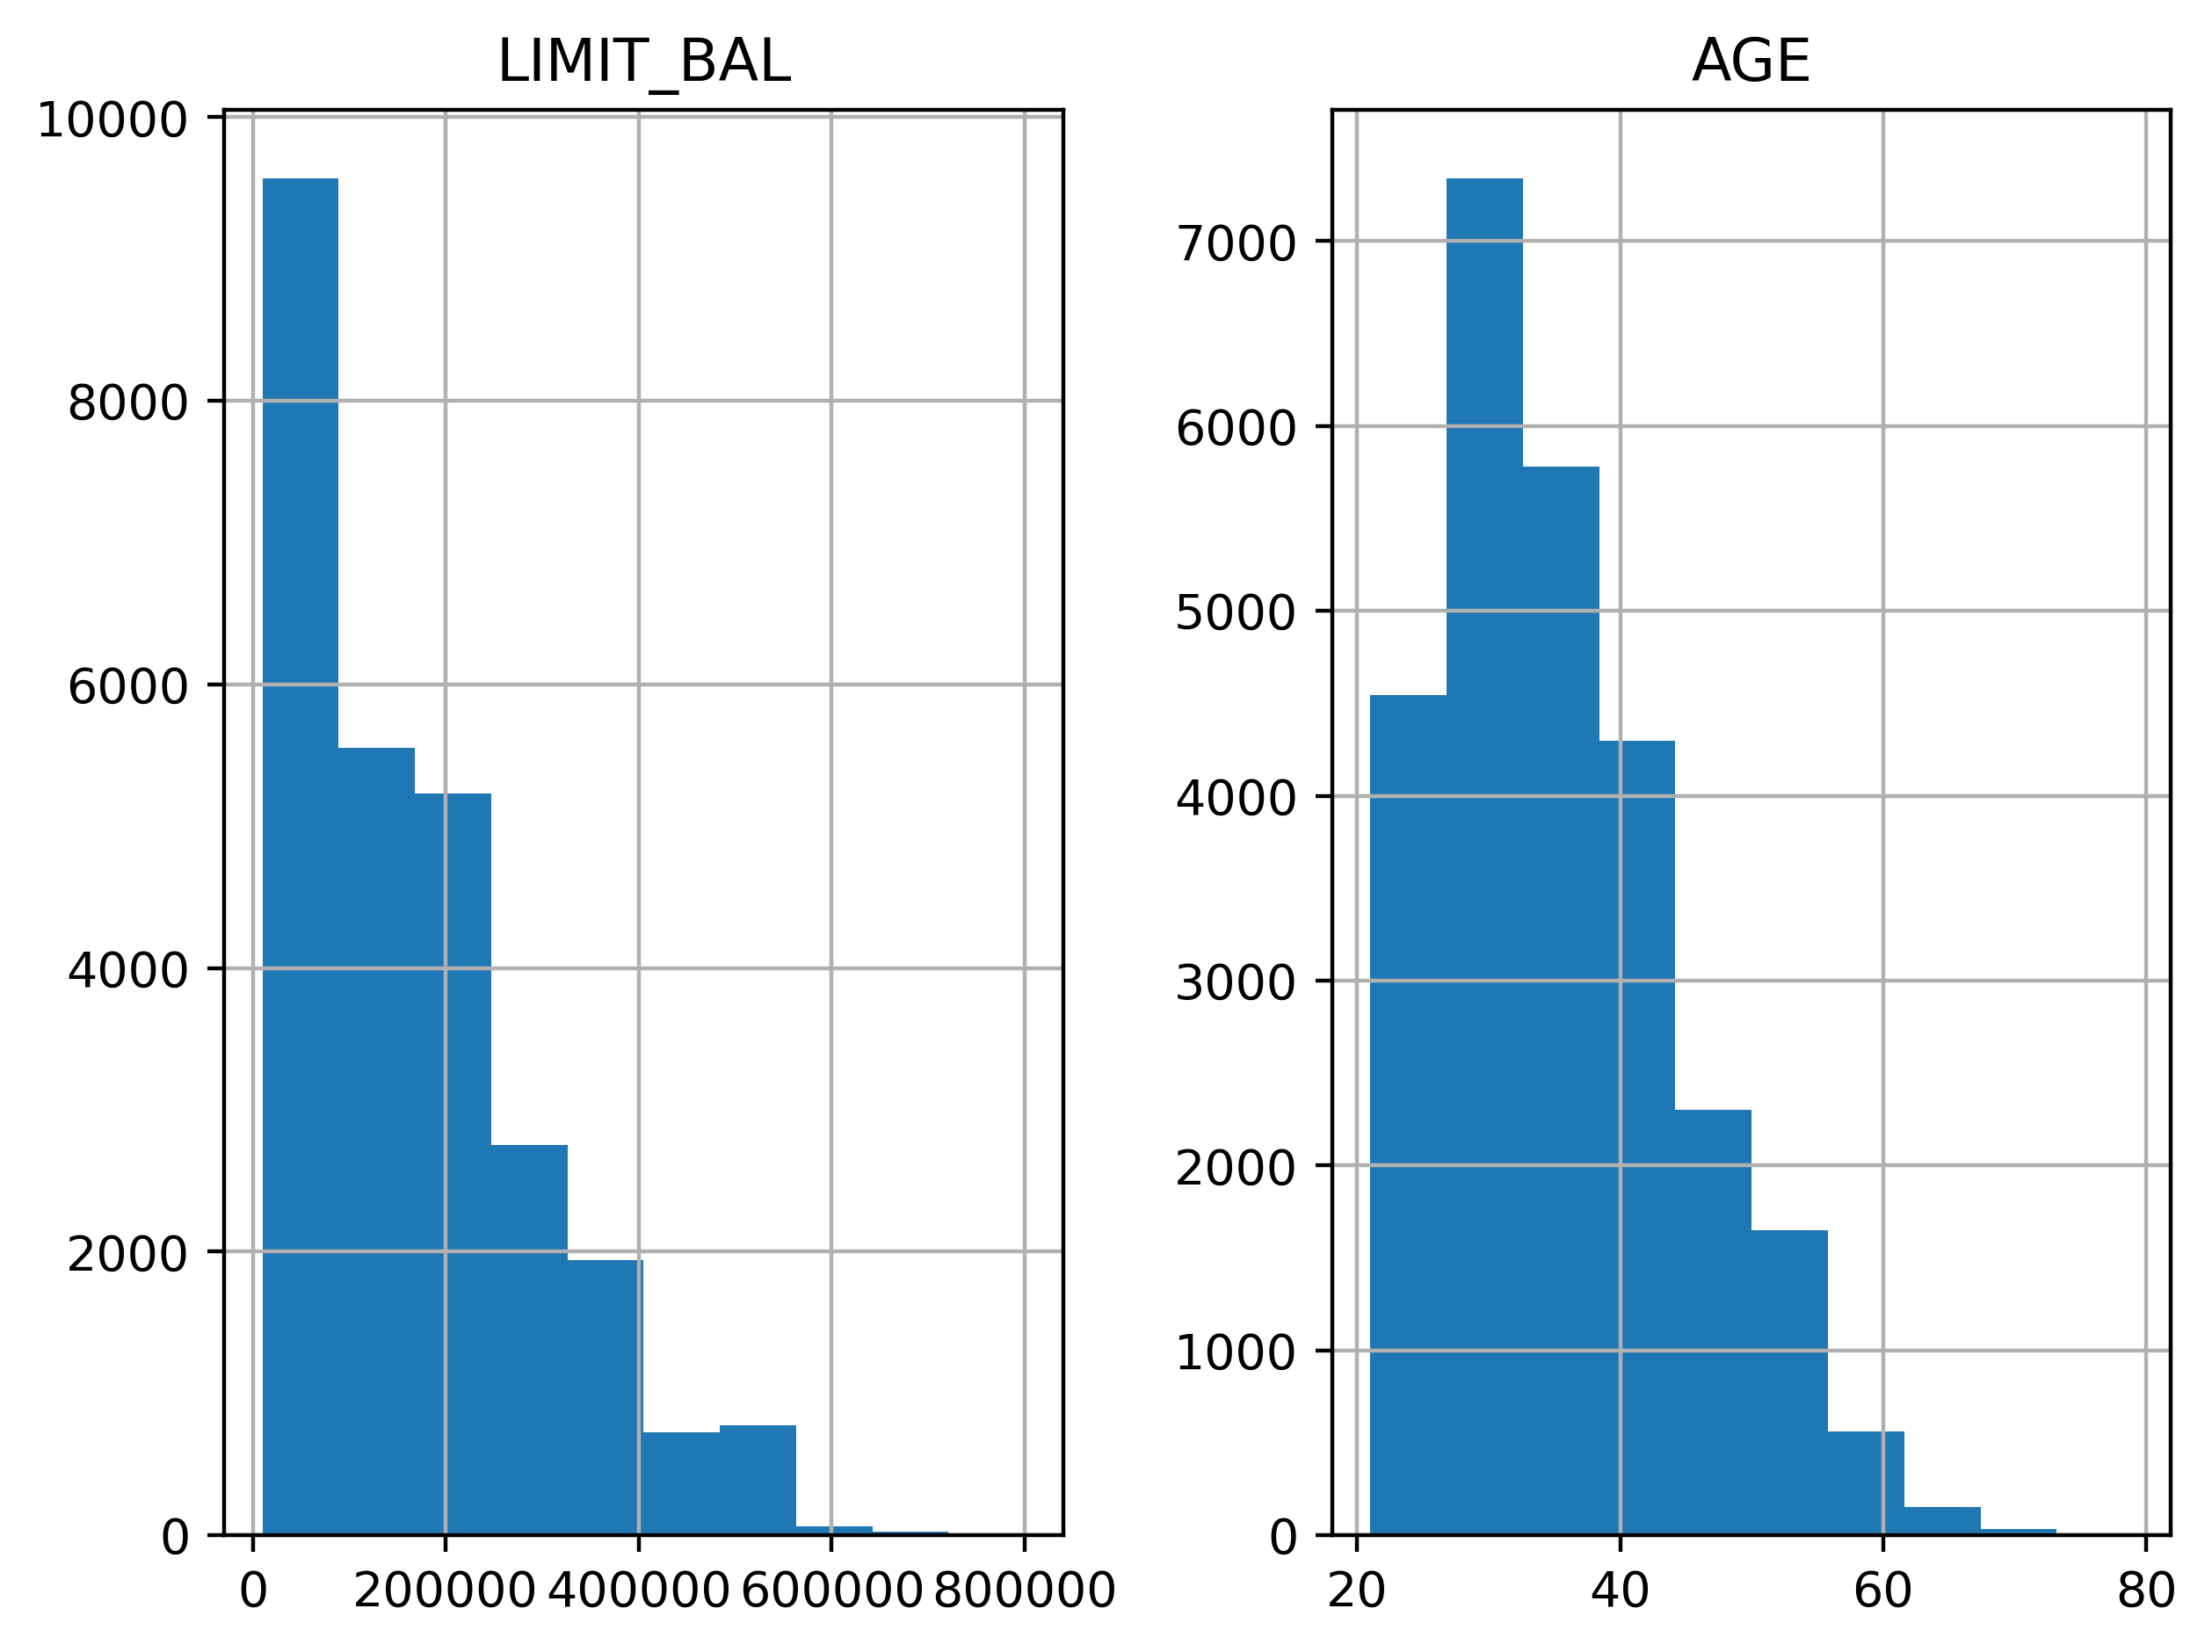

In [18]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

%matplotlib inline

mpl.rcParams['figure.dpi'] = 400

df_clean_2[['LIMIT_BAL', 'AGE']].hist()
plt.tight_layout()
plt.show()

In [19]:
df_clean_2[['LIMIT_BAL', 'AGE']].describe()

,LIMIT_BAL,AGE
count,26664.000000,26664.000000
mean,167919.054905,35.505213
std,129839.453081,9.227442
min,10000.000000,21.000000
25%,50000.000000,28.000000
50%,140000.000000,34.000000
75%,240000.000000,41.000000
max,800000.000000,79.000000


In [20]:
print("Thống kê EDUCATION trước khi chỉnh sửa:")
print(df_clean_2['EDUCATION'].value_counts())

# Chuyển các giá trị không xác định (0, 5, 6) thành 4 (Others)
df_clean_2['EDUCATION'] = df_clean_2['EDUCATION'].replace([0, 5, 6], 4)

# Kiểm tra lại
print("\nThống kê EDUCATION sau khi chỉnh sửa:")
print(df_clean_2['EDUCATION'].value_counts())

Thống kê EDUCATION trước khi chỉnh sửa:
EDUCATION
2    12458
1     9412
3     4380
5      245
4      115
6       43
0       11
Name: count, dtype: int64

Thống kê EDUCATION sau khi chỉnh sửa:
EDUCATION
2    12458
1     9412
3     4380
4      414
Name: count, dtype: int64


In [21]:
print("Thống kê MARRIAGE trước khi chỉnh sửa:")
print(df_clean_2['MARRIAGE'].value_counts())

# Chuyển giá trị 0 thành 3 (Others)
df_clean_2['MARRIAGE'] = df_clean_2['MARRIAGE'].replace(0, 3)

# Kiểm tra lại
print("\nThống kê MARRIAGE sau khi chỉnh sửa:")
print(df_clean_2['MARRIAGE'].value_counts())

Thống kê MARRIAGE trước khi chỉnh sửa:
MARRIAGE
2    14158
1    12172
3      286
0       48
Name: count, dtype: int64

Thống kê MARRIAGE sau khi chỉnh sửa:
MARRIAGE
2    14158
1    12172
3      334
Name: count, dtype: int64


In [22]:
df_clean_2.to_csv('credit_card_clean_2_updated.csv', index=False)
print("Đã cập nhật và lưu file thành công!")

Đã cập nhật và lưu file thành công!


## **3.3. Bài tập 3. Gán nhãn các dữ liệu**

In [23]:
df_clean_2['EDUCATION_CAT'] = 'none'

print("10 dòng đầu trước khi thực hiện mapping:")
display(df_clean_2[['EDUCATION', 'EDUCATION_CAT']].head(10))

cat_mapping = {
    1: "graduate school",
    2: "university",
    3: "high school",
    4: "others"
}

df_clean_2['EDUCATION_CAT'] = df_clean_2['EDUCATION'].map(cat_mapping)

print("\n10 dòng đầu sau khi thực hiện mapping:")
display(df_clean_2[['EDUCATION', 'EDUCATION_CAT']].head(10))

10 dòng đầu trước khi thực hiện mapping:


,EDUCATION,EDUCATION_CAT
0,2,none
1,2,none
2,2,none
3,2,none
4,2,none
5,1,none
6,1,none
7,2,none
8,3,none
9,3,none



10 dòng đầu sau khi thực hiện mapping:


,EDUCATION,EDUCATION_CAT
0,2,university
1,2,university
2,2,university
3,2,university
4,2,university
5,1,graduate school
6,1,graduate school
7,2,university
8,3,high school
9,3,high school


In [24]:
edu_ohe = pd.get_dummies(df_clean_2['EDUCATION_CAT'])

print("Dữ liệu dummy code (10 dòng đầu):")
display(edu_ohe.head(10))

df_2 = pd.concat([df_clean_2, edu_ohe], axis=1)

print("\nKết quả sau khi gắn kết (df_2):")
display(df_2[['EDUCATION_CAT', 'graduate school', 'high school', 'university', 'others']].head(10))

Dữ liệu dummy code (10 dòng đầu):


,graduate school,high school,others,university
0,False,False,False,True
1,False,False,False,True
2,False,False,False,True
3,False,False,False,True
4,False,False,False,True
5,True,False,False,False
6,True,False,False,False
7,False,False,False,True
8,False,True,False,False
9,False,True,False,False



Kết quả sau khi gắn kết (df_2):


,EDUCATION_CAT,graduate school,high school,university,others
0,university,False,False,True,False
1,university,False,False,True,False
2,university,False,False,True,False
3,university,False,False,True,False
4,university,False,False,True,False
5,graduate school,True,False,False,False
6,graduate school,True,False,False,False
7,university,False,False,True,False
8,high school,False,True,False,False
9,high school,False,True,False,False


In [25]:
df_2.to_csv('credit_card_clean_3.csv', index=False)

print("Đã hoàn thành Bài tập 3 và lưu file thành công!")

Đã hoàn thành Bài tập 3 và lưu file thành công!


## **3.4. Tìm hiểu các phương pháp vẽ đồ thị từ thư viện matplotlib**

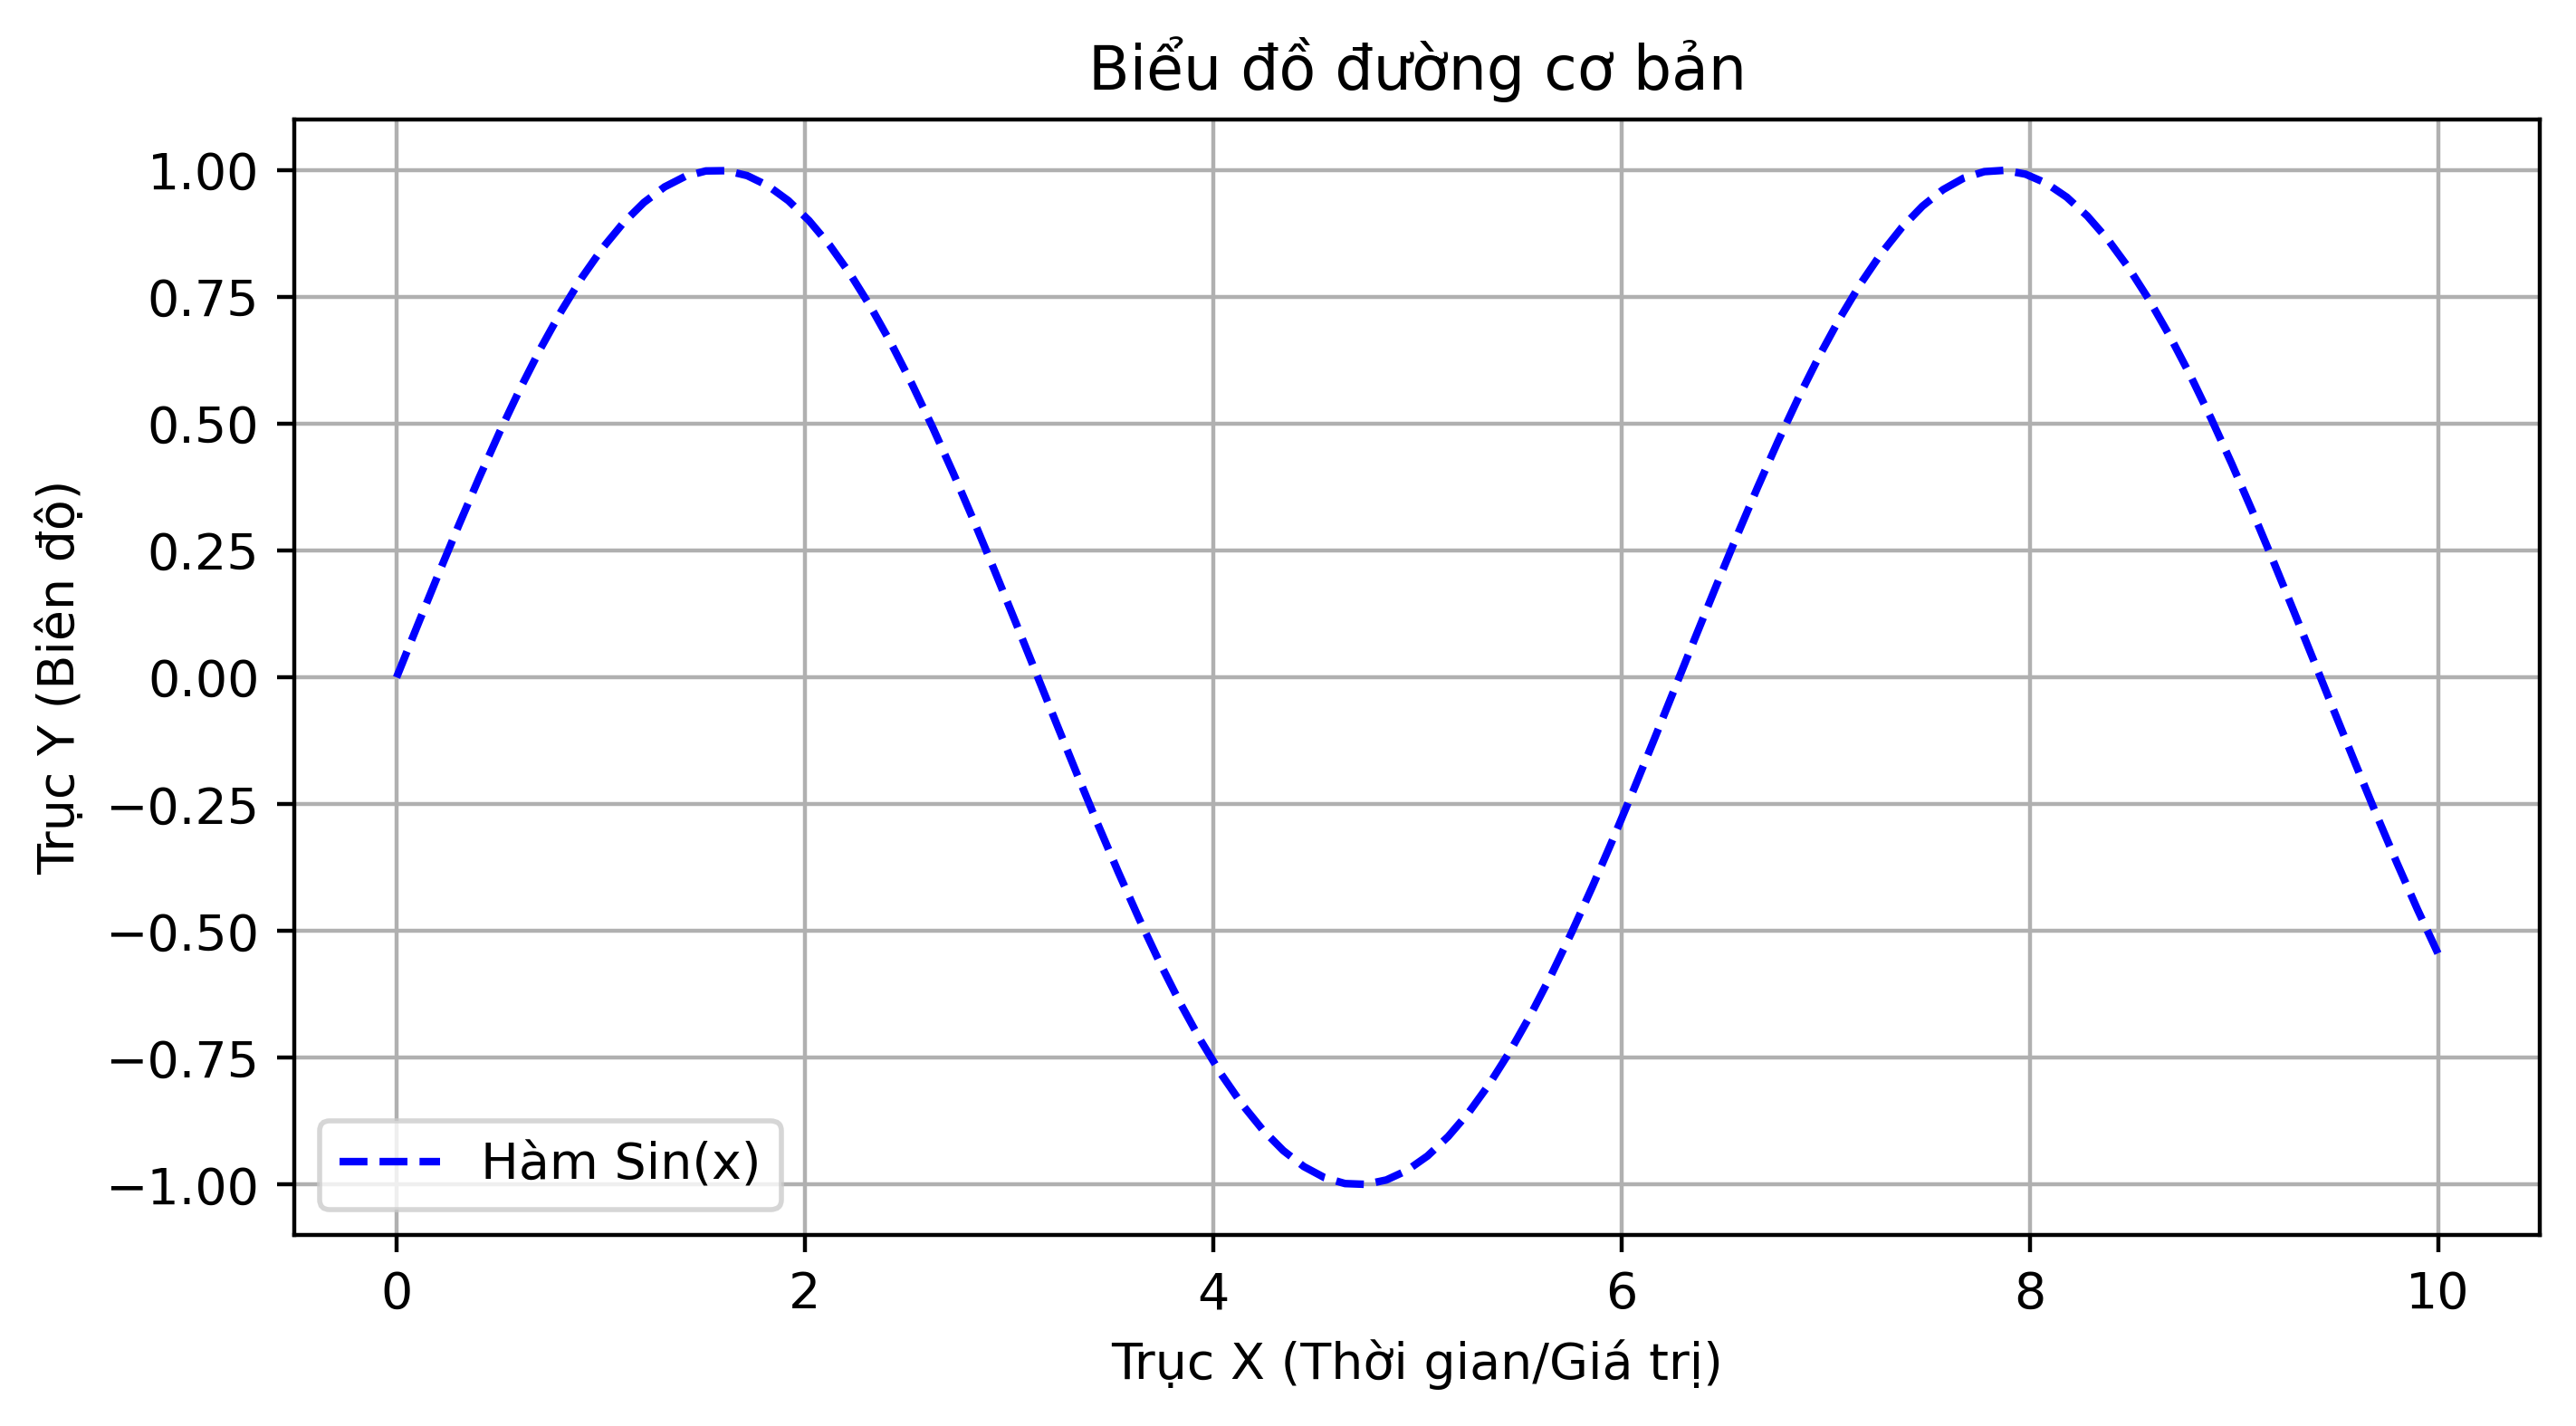

In [26]:
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, label='Hàm Sin(x)', color='blue', linestyle='--') # Vẽ đường

plt.title("Biểu đồ đường cơ bản")
plt.xlabel("Trục X (Thời gian/Giá trị)")
plt.ylabel("Trục Y (Biên độ)")
plt.legend()
plt.grid(True)
plt.show()

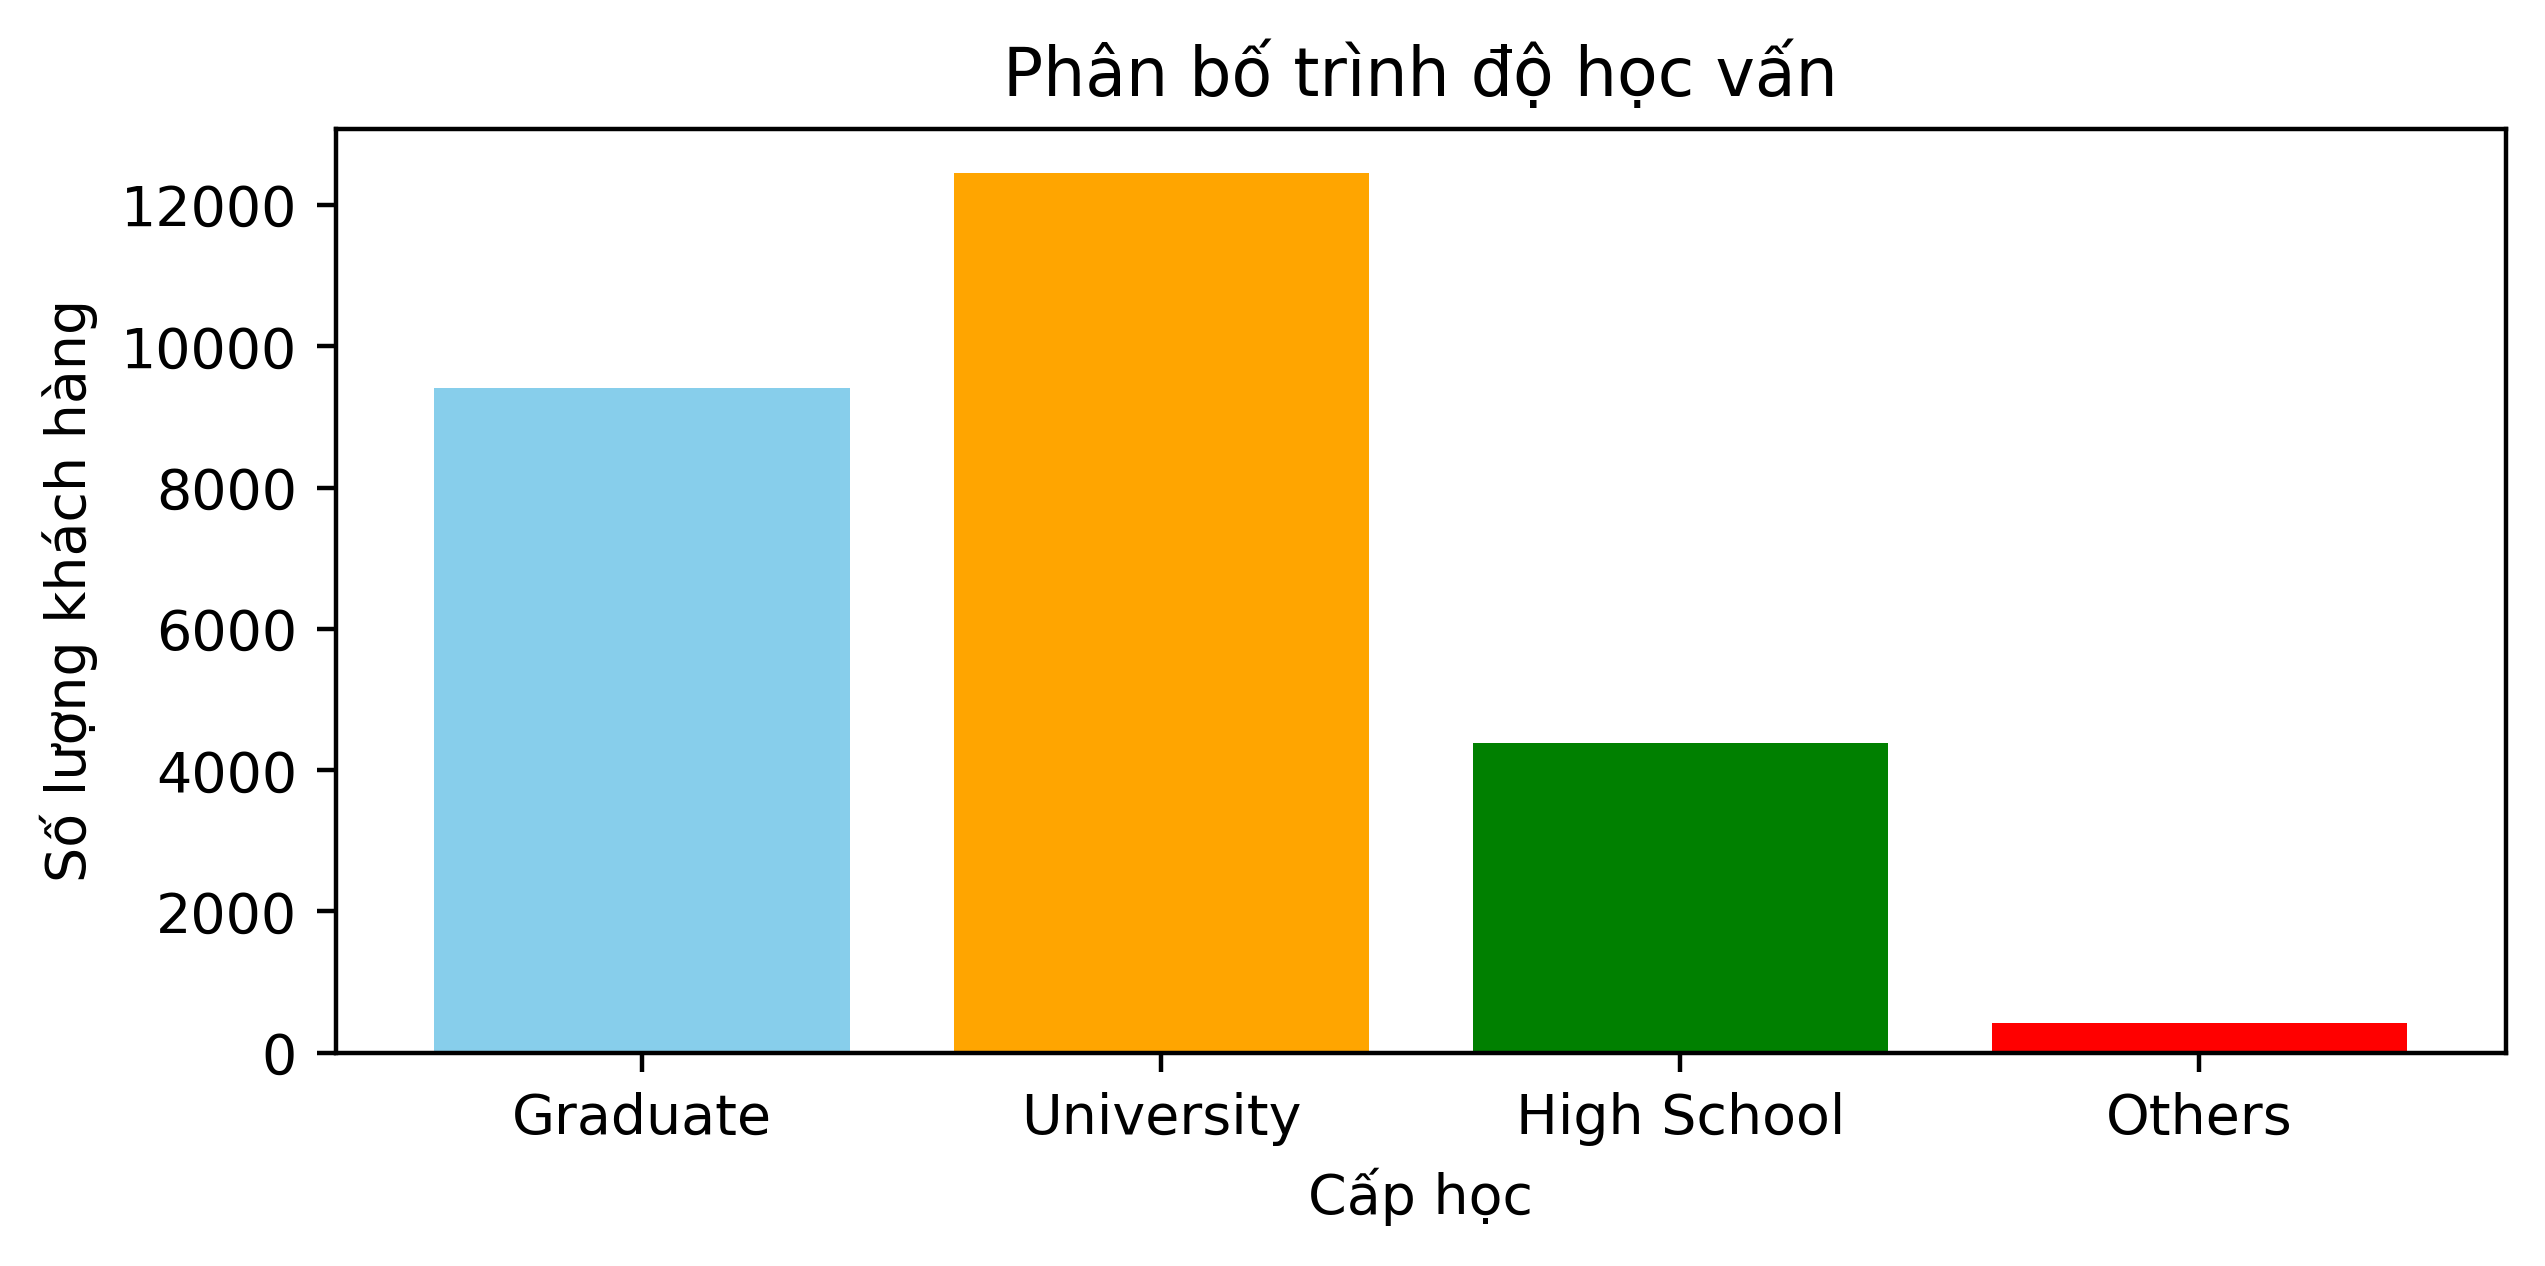

In [30]:
categories = ['Graduate', 'University', 'High School', 'Others']
values = [9412, 12458, 4380, 414]

plt.figure(figsize=(7, 3))
plt.bar(categories, values, color=['skyblue', 'orange', 'green', 'red'])

plt.title("Phân bố trình độ học vấn")
plt.xlabel("Cấp học")
plt.ylabel("Số lượng khách hàng")
plt.show()

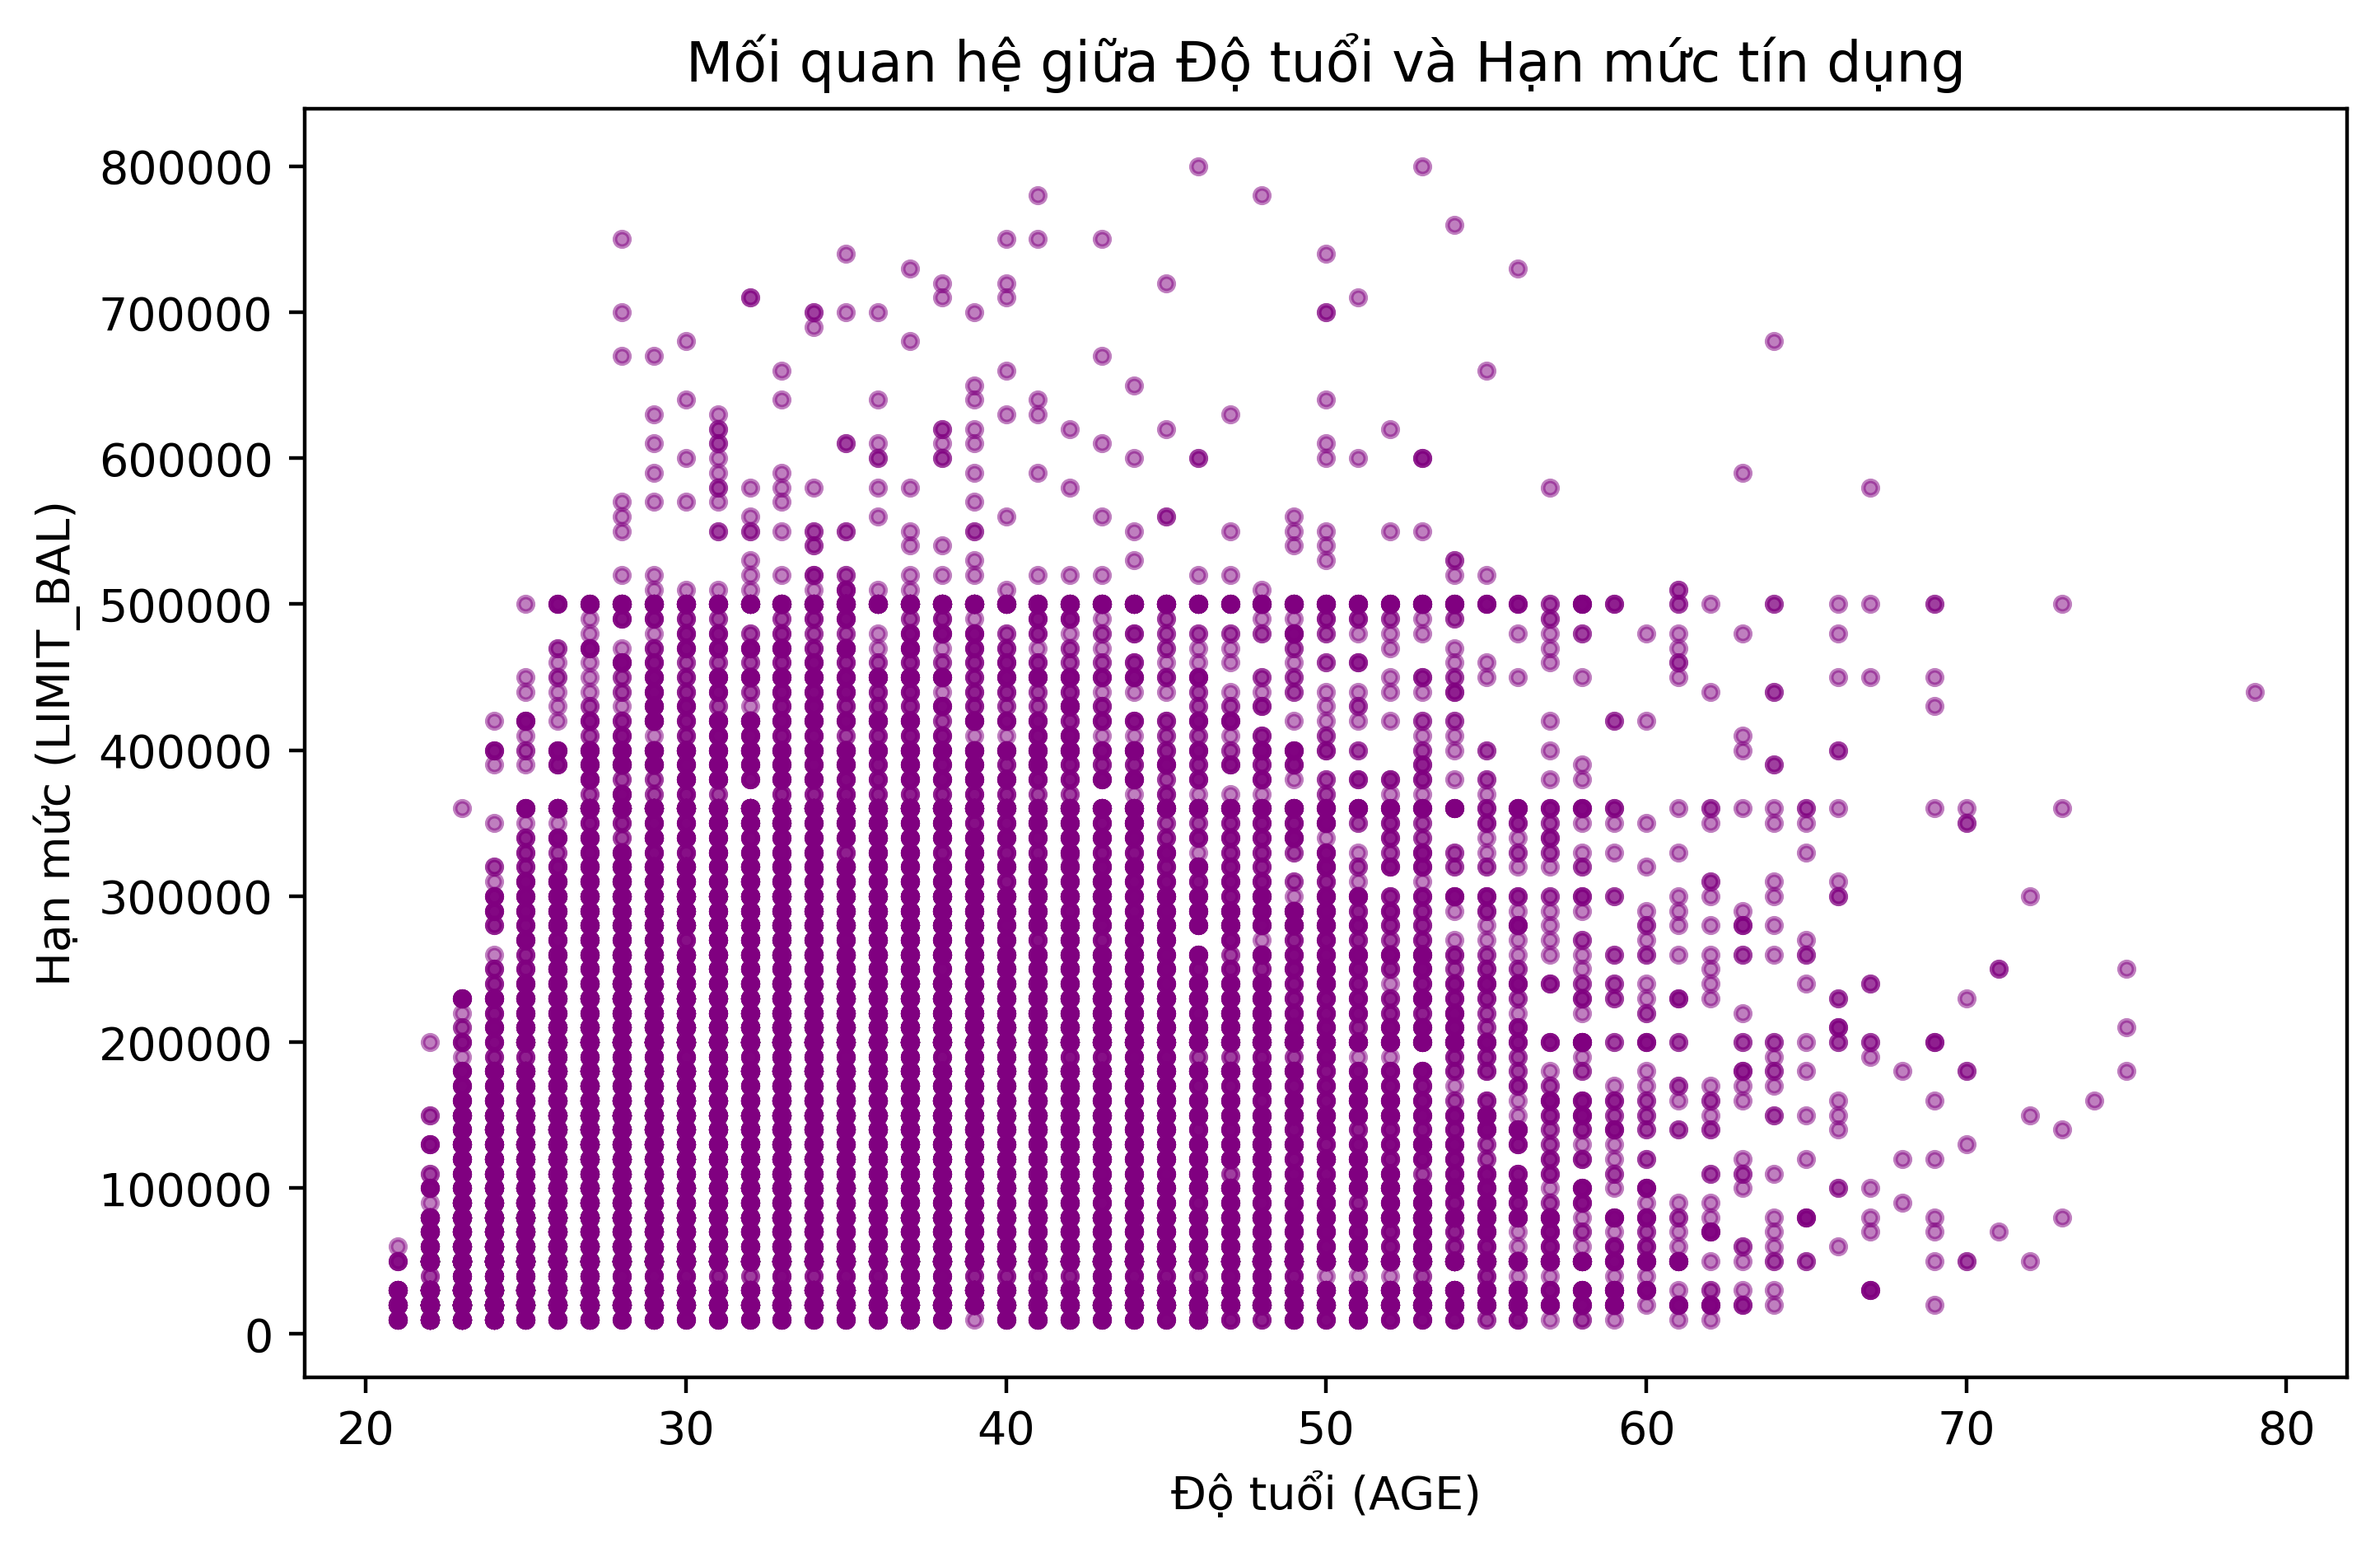

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean_2['AGE'], df_clean_2['LIMIT_BAL'], alpha=0.5, s=10, c='purple')

plt.title("Mối quan hệ giữa Độ tuổi và Hạn mức tín dụng")
plt.xlabel("Độ tuổi (AGE)")
plt.ylabel("Hạn mức (LIMIT_BAL)")
plt.show()

## **3.5. Vẽ các biểu đồ**

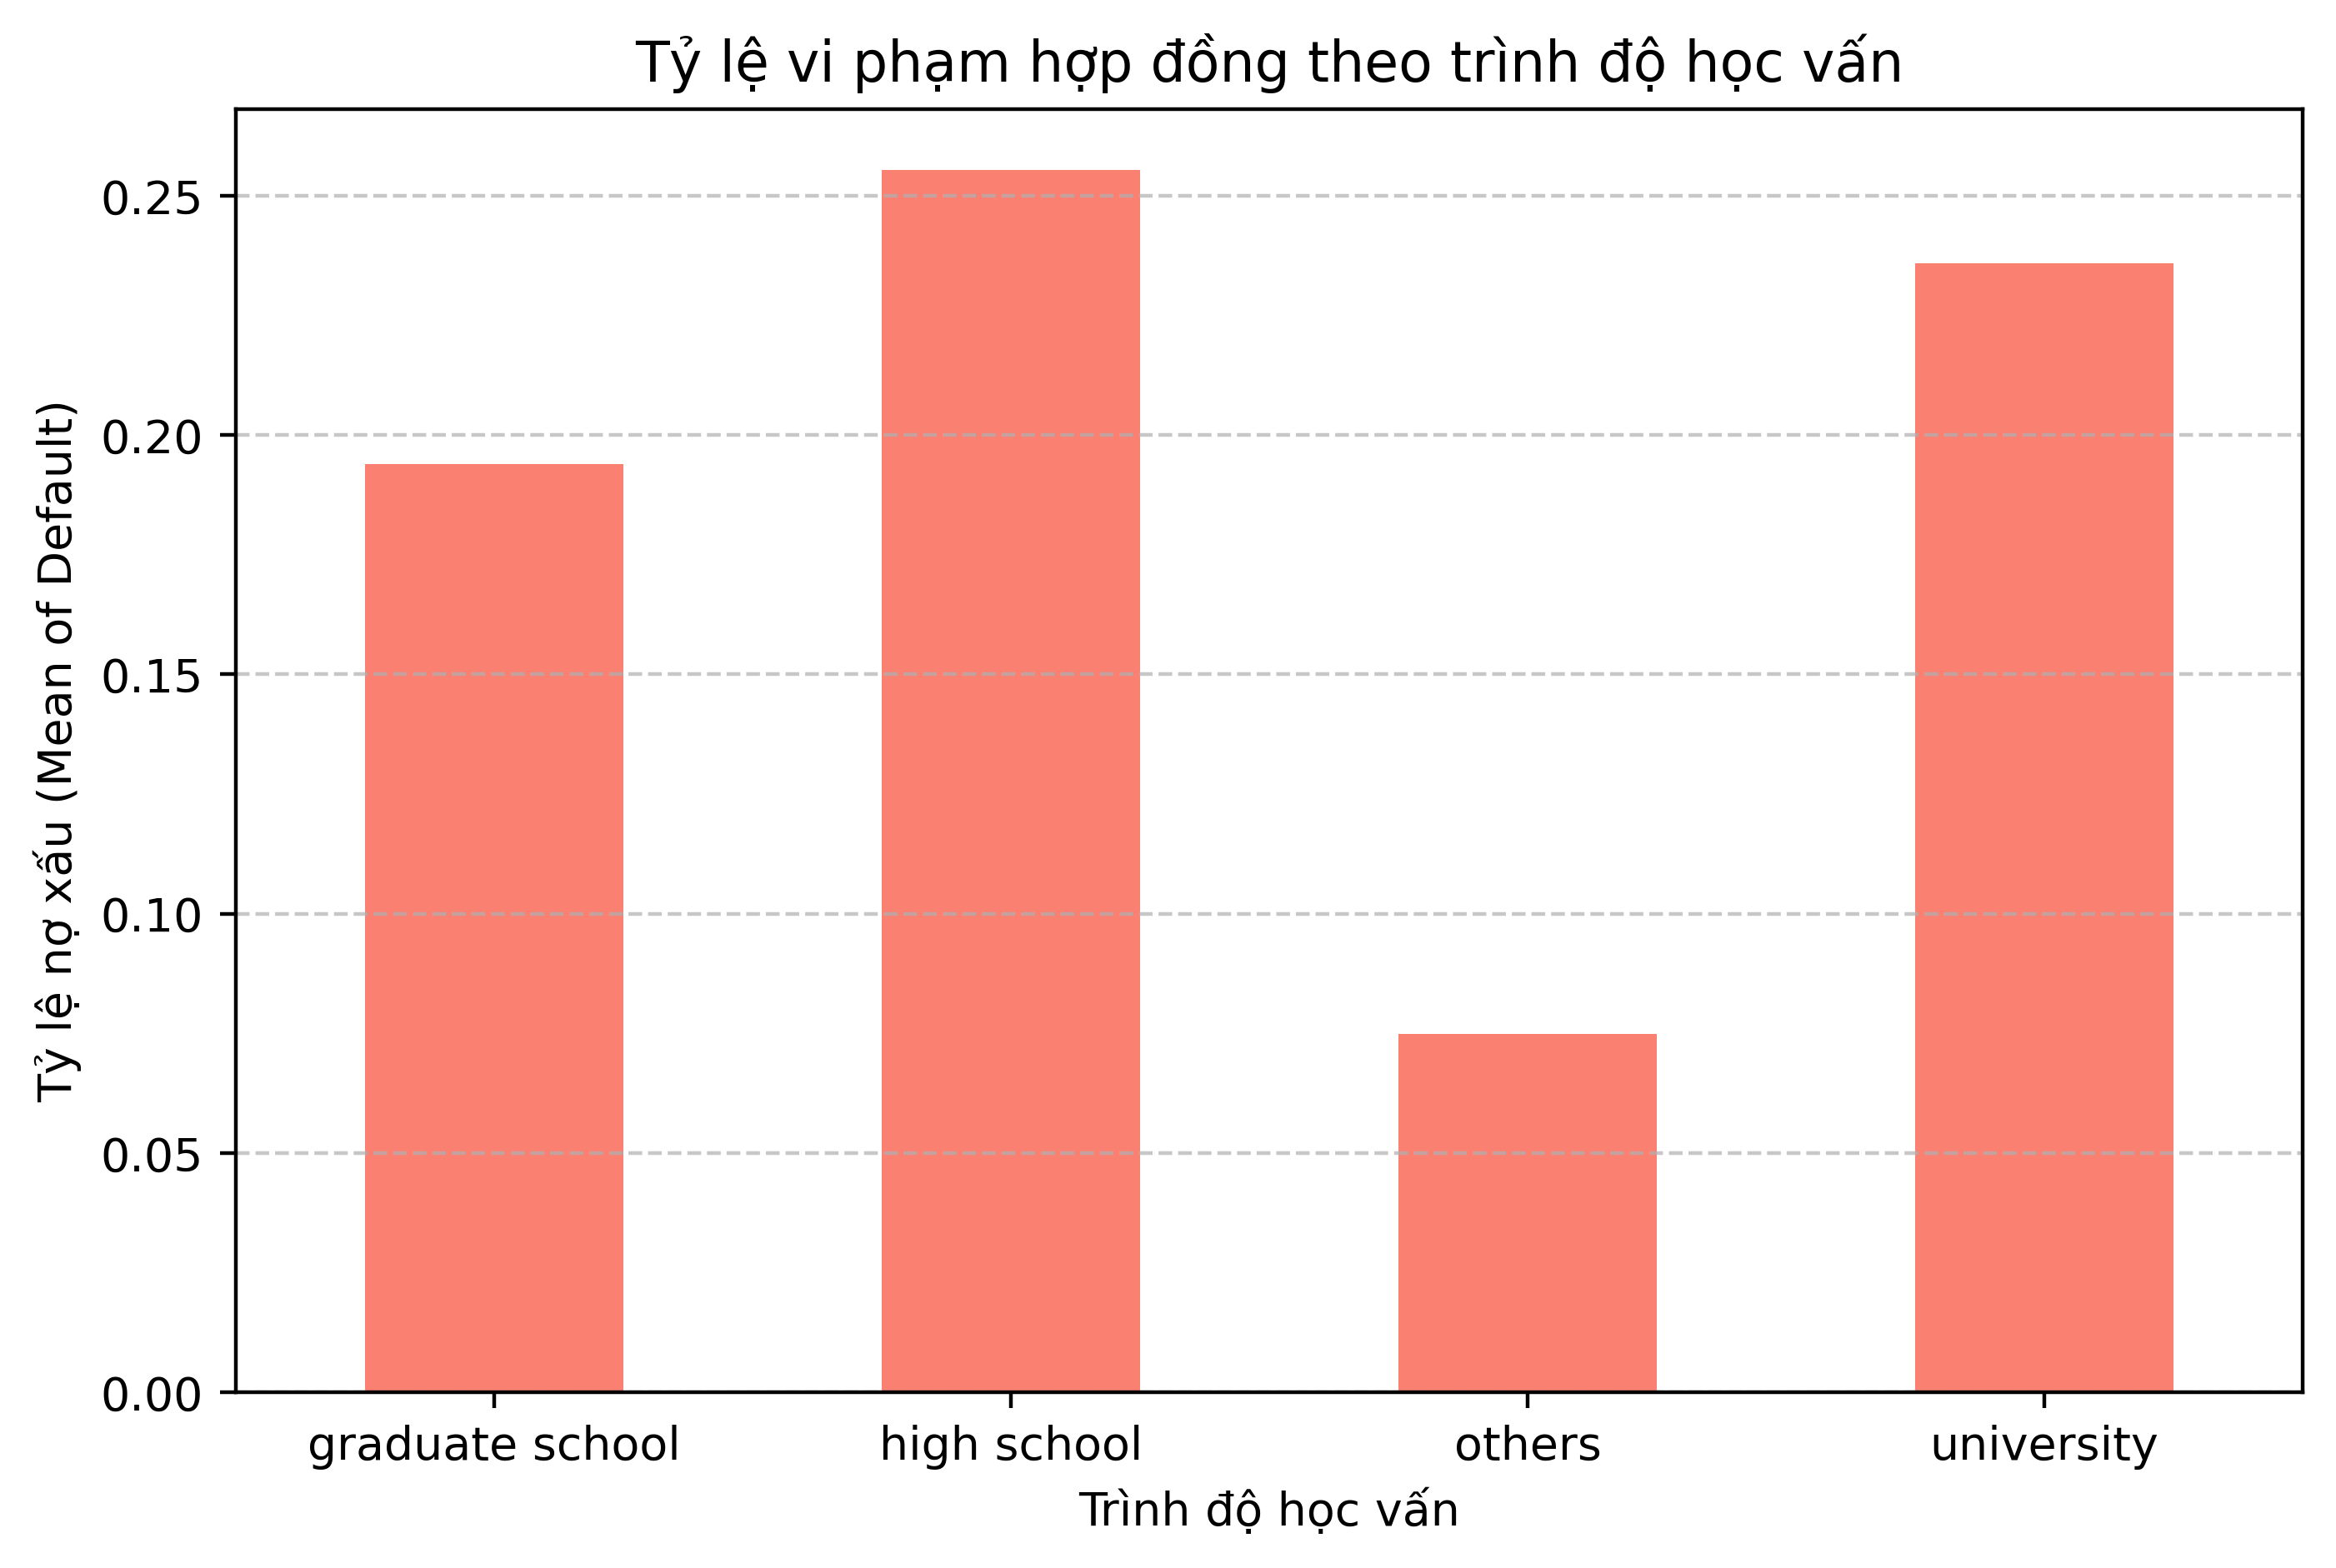

In [31]:
edu_default_rate = df_2.groupby('EDUCATION_CAT')['default payment next month'].mean()

plt.figure(figsize=(8, 5))
edu_default_rate.plot(kind='bar', color='salmon')

plt.title('Tỷ lệ vi phạm hợp đồng theo trình độ học vấn')
plt.xlabel('Trình độ học vấn')
plt.ylabel('Tỷ lệ nợ xấu (Mean of Default)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

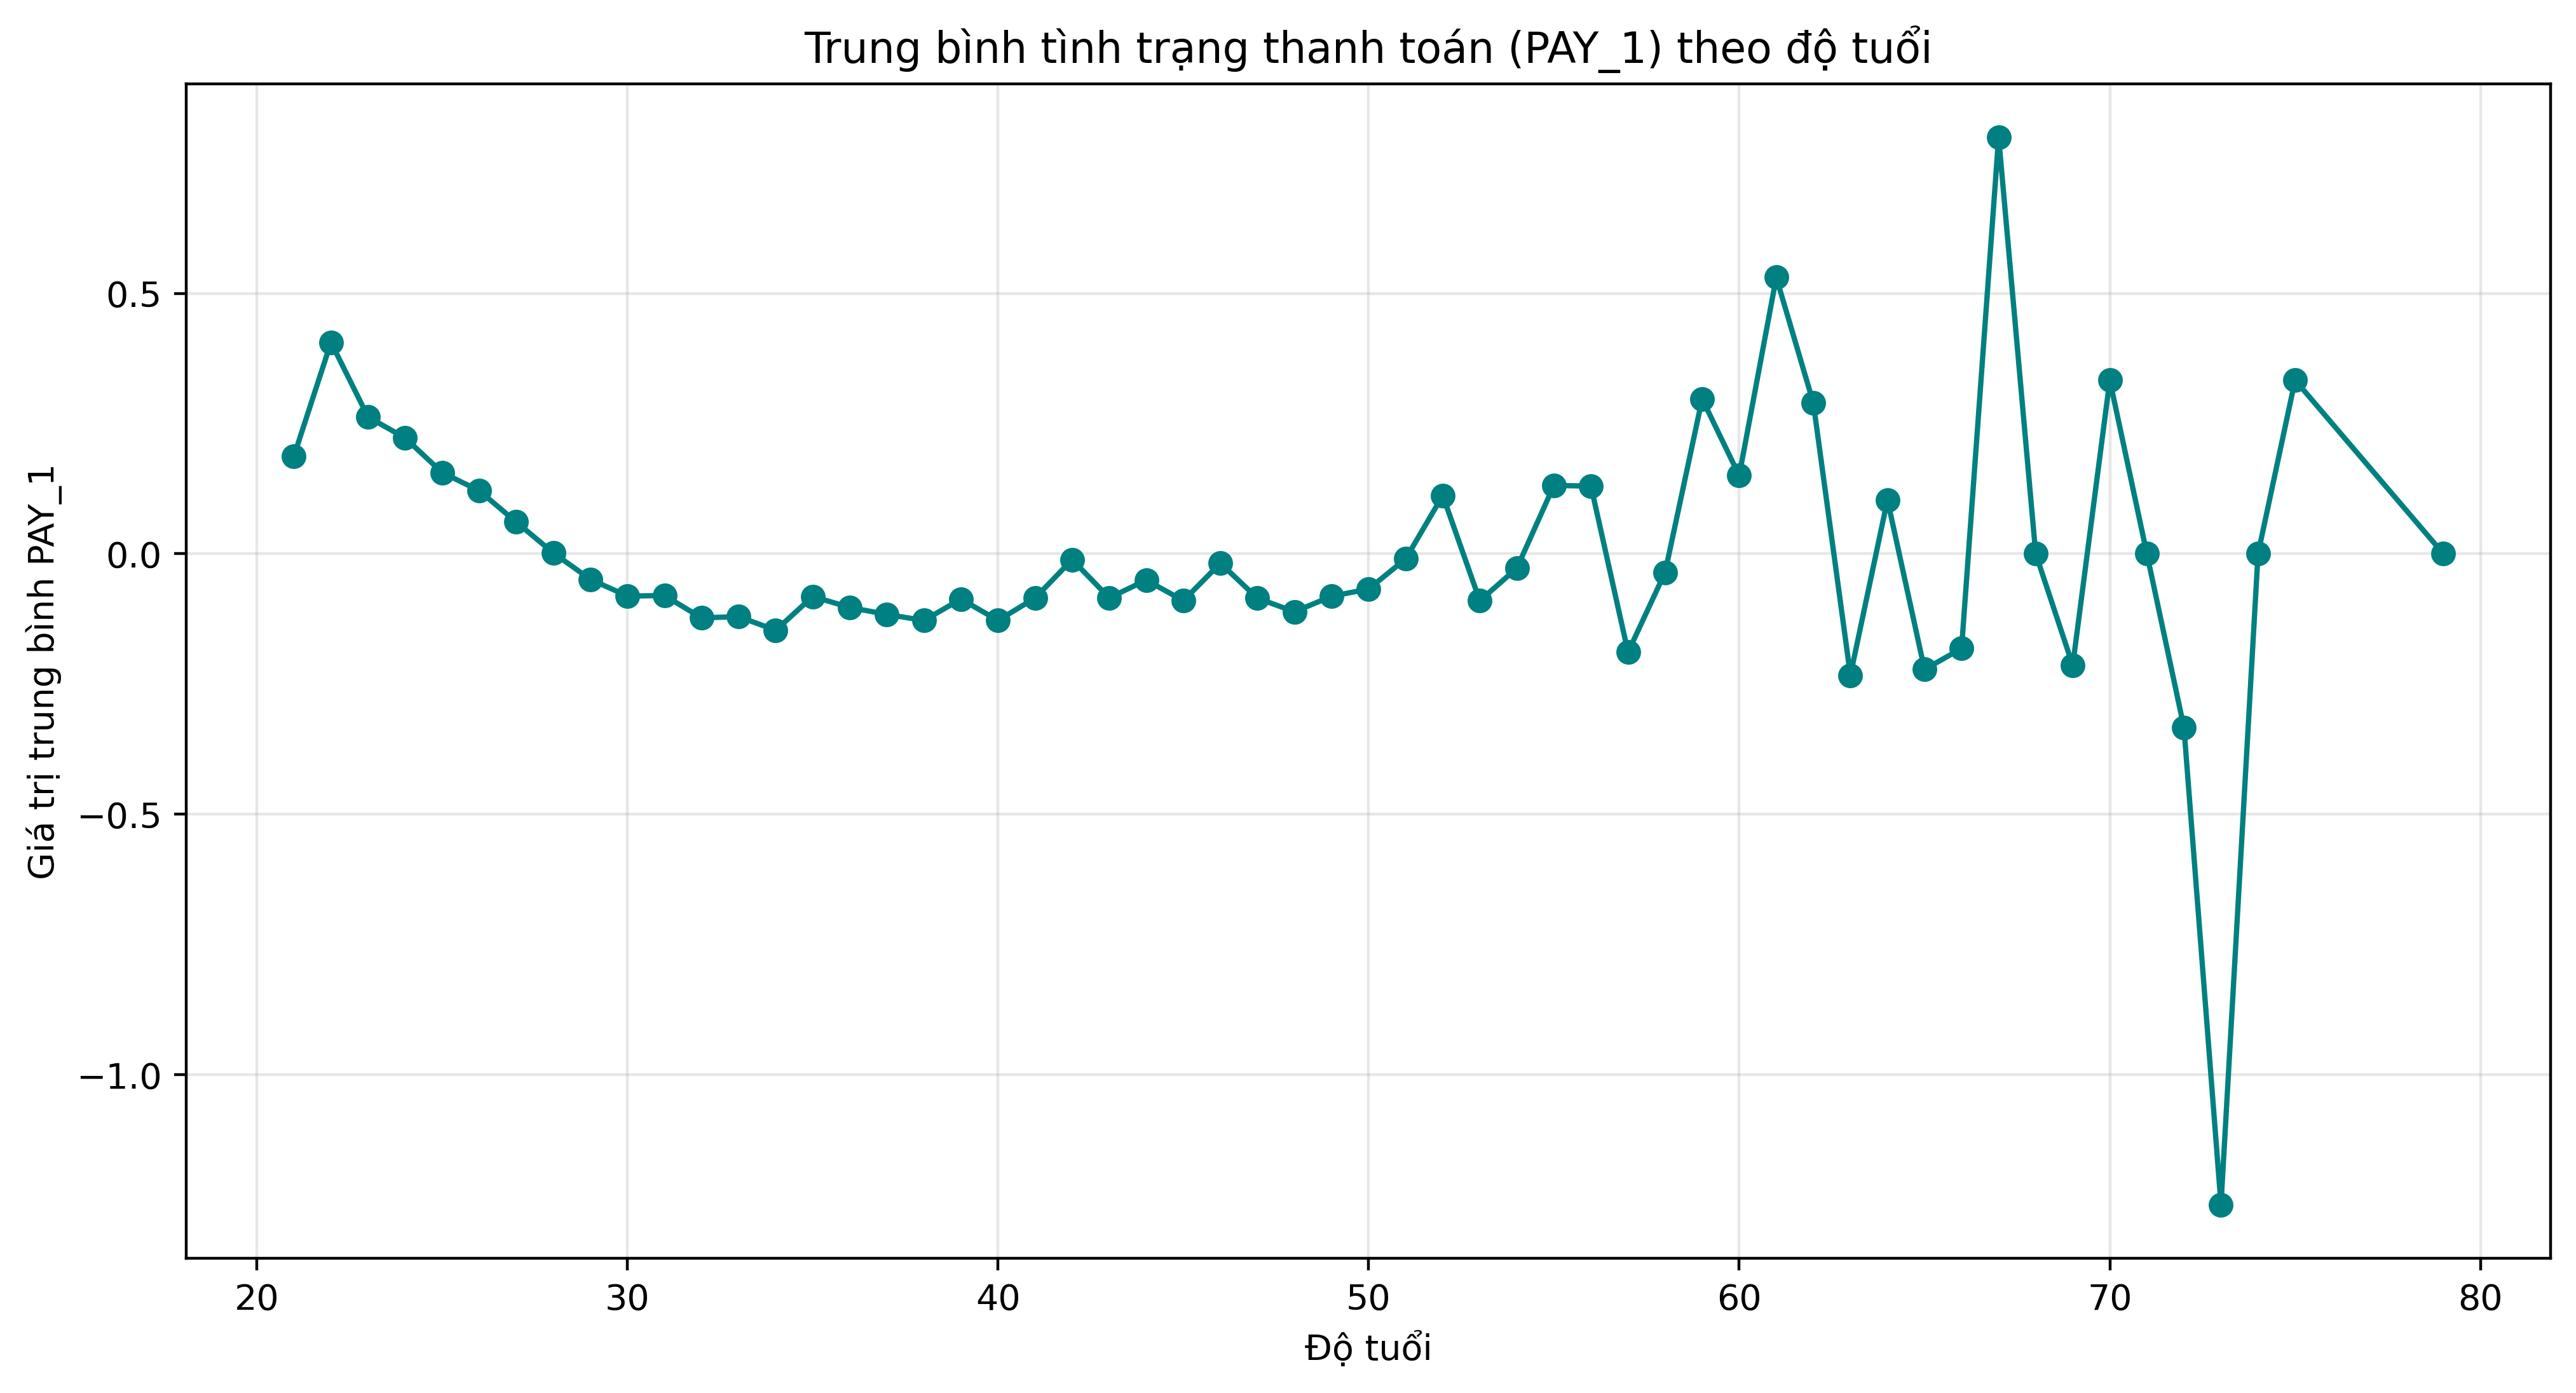

In [32]:
age_pay_mean = df_2.groupby('AGE')['PAY_1'].mean()

plt.figure(figsize=(12, 6))
plt.plot(age_pay_mean.index, age_pay_mean.values, marker='o', linestyle='-', color='teal')

plt.title('Trung bình tình trạng thanh toán (PAY_1) theo độ tuổi')
plt.xlabel('Độ tuổi')
plt.ylabel('Giá trị trung bình PAY_1')
plt.grid(True, alpha=0.3)
plt.show()

## Tổng kết tập dữ liệu credit_card_clean_3.csv

Sau quá trình làm sạch và gán nhãn dữ liệu, tập dữ liệu cuối cùng có các thông số sau:

- **Số lượng dòng:** 26,664 dòng (sau khi loại bỏ các dòng 'Not available').
- **Số lượng cột:** 30 cột (bao gồm 25 cột gốc, cột EDUCATION_CAT và 4 cột dummy variables).
- **Các thuộc tính mới thêm vào:** - `EDUCATION_CAT`: Nhãn văn bản của trình độ học vấn.
  - `graduate school`, `high school`, `university`, `others`: Các cột biến giả (dummy variables).